Thomas Sears

9-13-26

Lab 3 - Oscillator Simulation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Part A — The Simple Harmonic Oscillator

Description: Takes a modified version of the simulate() function, simulate_sho(), and extends it to SHM. This function simulates a point mass oscillating on a spring and compares the effectiveness of both the Euler and Euler-Cromer methods in dealing with a SHM simulation. It also plots the postion as a function of time, x(t), and energy vs time for each method with an overlayed exact solution for the x(t) plot.

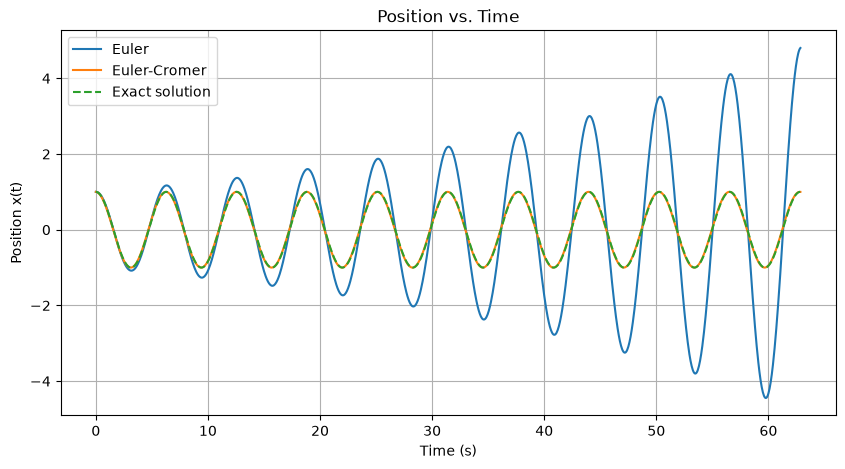

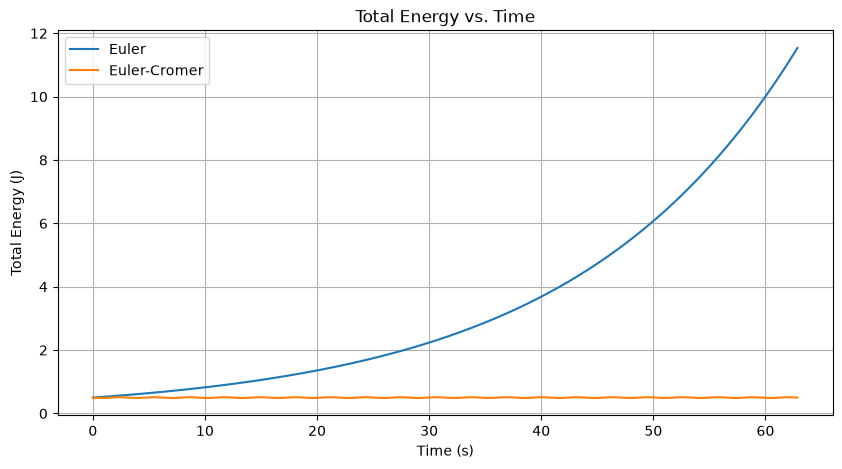

In [2]:
#Parameters
x0 = 1.0
v0 = 0.0
k = 1.0
m = 1.0
omega = np.sqrt(k / m)
T = 2 * np.pi / omega

def simulate_sho(method, dt, n_periods=10):

    #Initial condiditons

    t_max = n_periods * T
    x, v = x0, v0
    ts, xs, vs, Es = [0], [x], [v], [0.5*k*x**2 + 0.5*m*v**2]
    t = 0.0

    while t < t_max:
        a = -(k / m) * x

        if method == 'euler':
            x = x + v * dt
            v = v + a * dt
        elif method == 'euler-cromer':
            v = v + a * dt
            x = x + v * dt  

        t += dt
        E = 0.5 * k * x**2 + 0.5 * m * v**2
        ts.append(t); xs.append(x); vs.append(v); Es.append(E)

    return np.array(ts), np.array(xs), np.array(vs), np.array(Es)

dt = 0.05
t_e, x_e, v_e, E_e = simulate_sho('euler', dt)
t_ec, x_ec, v_ec, E_ec = simulate_sho('euler-cromer', dt)

# Plot #1 - x(t)

t_exact = np.linspace(0, 10*T, 1000)
x_exact = x0 * np.cos(omega * t_exact)

plt.figure(figsize=(10, 5))

plt.plot(t_e, x_e, label='Euler')
plt.plot(t_ec, x_ec, label='Euler-Cromer')
plt.plot(t_exact, x_exact, label='Exact solution', linestyle='--')

plt.xlabel('Time (s)')
plt.ylabel('Position x(t)')
plt.title('Position vs. Time')
plt.legend()
plt.grid()

plt.show()

# Plot #2 - Total Energy

plt.figure(figsize=(10, 5))

plt.plot(t_e, E_e, label='Euler')
plt.plot(t_ec, E_ec, label='Euler-Cromer')

plt.xlabel('Time (s)')
plt.ylabel('Total Energy (J)')
plt.title('Total Energy vs. Time')
plt.legend()
plt.grid()

plt.show()

Interpretation: 

As we see in the x(t) graph, the Euler method very quickly blows up to extremely high/non constant amplitudes. In addition to this, the energy-time graph shows the Euler method quickly increasing and not oscillating around a constant value like we would expect. This is contrasted by the Euler-Cromer method which approximates the exact solutions of x(t) very well at dt = 0.05. The Euler-Cromer method also does a much better job of approximating the total energy of the system with only minor deviations that oscillate around a constant energy value.

This shows the massive advantages of the Euler-Cromer method over the standard Euler method as the Euler-Cromer method is a symplectic integrator which allows the error to stay bounded for each oscillation rather than growing over time.

Part B — Phase Space & Damped Oscillations 

Description: First plots a phase-space diagram for both Euler and Euler-Cromer. This plot will show why Euler-Cromer is the prefered method. Next, a new damping function is used to simulate the 3 case of damping for SHM, underdamping, overdamping, and critical damping. Then, a plot of x(t) and the phase-space for each method is shown which compares the differences for each damping coefficient.

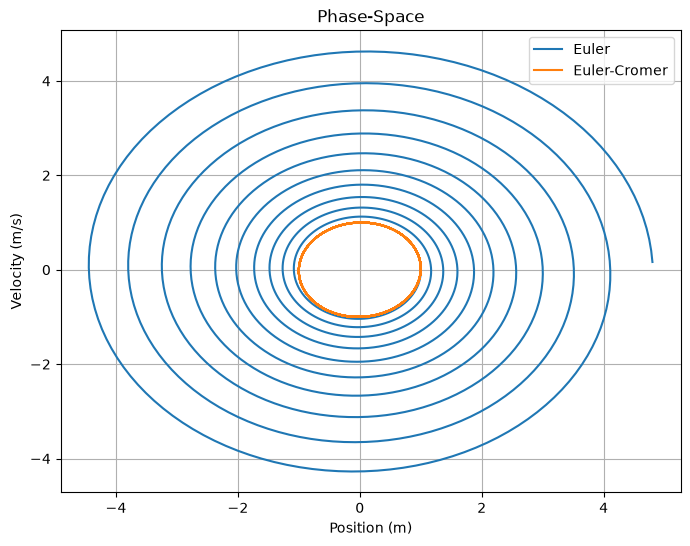

In [3]:
# Plot - phase-space

plt.figure(figsize=(8, 6))

plt.plot(x_e, v_e, label='Euler')
plt.plot(x_ec, v_ec, label='Euler-Cromer')

plt.xlabel('Position (m)')
plt.ylabel('Velocity (m/s)')
plt.title('Phase-Space')
plt.legend()
plt.grid()

plt.show()

Interpretation:

In this phase-space plot, we see that the Euler method forms a spiral pattern with both position and velocity increasing with time. On the other hand, the Euler-Cromer method forms an elipse with only slight roughness around the elipse, it does not spiral. This is expected because the total energy in the Euler-Cromer method is approximately conserved which means the kinetic and potential terms in the total energy expression are always equal to a constant, giving the eliptic shape. For the Euler method, energy is not properly conserved and instead diverges which explains the spiral shape of the phase-space diagram. If total energy increases, both kinetic and potential energy increases with time.

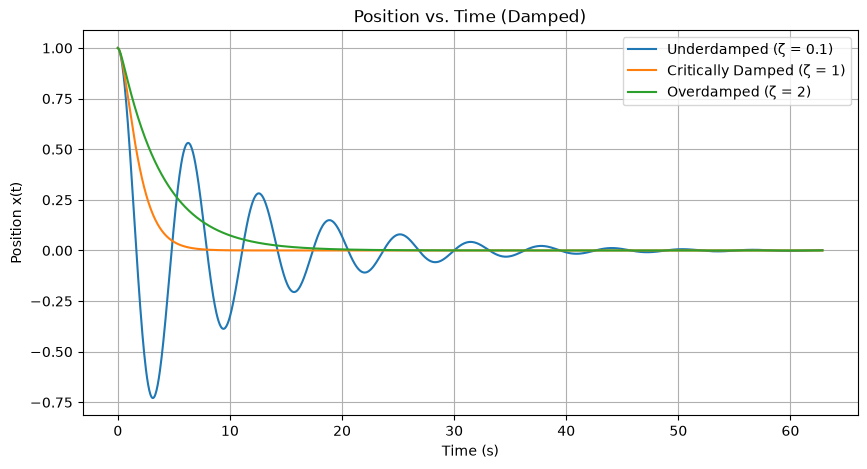

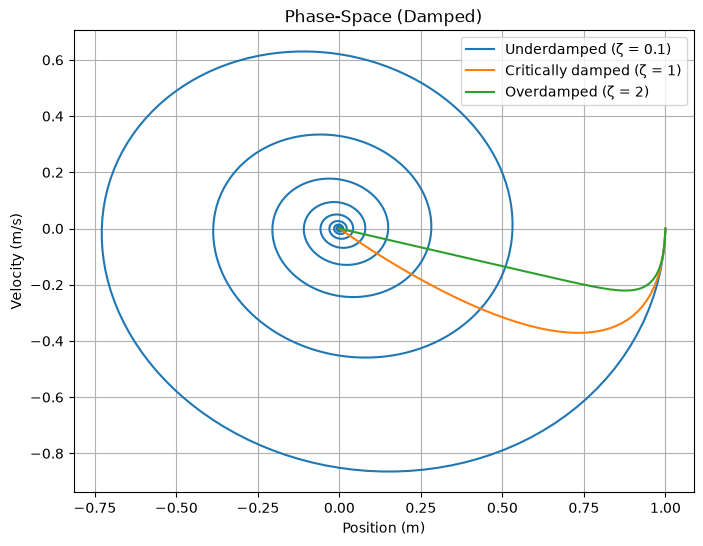

In [4]:
# New funcition only utilizing Euler-Cromer

def simulate_damped_sho(b, dt, n_periods=10):

    t_max = n_periods * T
    x, v = x0, v0

    ts = [0]
    xs = [x]
    vs = [v]

    t = 0.0

    while t < t_max:

        # Acceleration with damping
        a = -(k / m) * x - (b / m) * v

        # Euler-Cromer
        v = v + a * dt
        x = x + v * dt

        t += dt

        ts.append(t)
        xs.append(x)
        vs.append(v)

    return np.array(ts), np.array(xs), np.array(vs)


# Damping values (assumes k = m = 1)
b_under = 0.2  
b_critical = 2.0  
b_over = 4.0    

# All three cases
t_under, x_under, v_under = simulate_damped_sho(b_under, dt)
t_critical, x_critical, v_critical = simulate_damped_sho(b_critical, dt)
t_over, x_over, v_over = simulate_damped_sho(b_over, dt)


# Plot #1 - Position vs time
plt.figure(figsize=(10, 5))

plt.plot(t_under, x_under, label='Underdamped (ζ = 0.1)')
plt.plot(t_critical, x_critical, label='Critically Damped (ζ = 1)')
plt.plot(t_over, x_over, label='Overdamped (ζ = 2)')

plt.xlabel('Time (s)')
plt.ylabel('Position x(t)')
plt.title('Position vs. Time (Damped)')
plt.legend()
plt.grid()

plt.show()


# Plot #2 - Phase-space
plt.figure(figsize=(8, 6))

plt.plot(x_under, v_under, label='Underdamped (ζ = 0.1)')
plt.plot(x_critical, v_critical, label='Critically damped (ζ = 1)')
plt.plot(x_over, v_over, label='Overdamped (ζ = 2)')

plt.xlabel('Position (m)')
plt.ylabel('Velocity (m/s)')
plt.title('Phase-Space (Damped)')
plt.legend()
plt.grid()

plt.show()

Interpretation:

In the underdamped case, the phase-space plot shows a spiral structure similar to the one from the Euler method earlier but this time it spirals into the origin because the oscillator is losing energy with each oscillation. In the overdamped case, there is no oscillations and instead the mass slowly comes back to the origin without crossing to the negative x-axis. The the critically damped case, the mass returns to the origin even faster as shown in the phase-space diagram and just like the overdamped case, the mass does not oscillate.

Part C — Driven Oscillations & Resonance

Description: Modifies the previous damped simulation by now adding a driving force to the system. The code simulates this system with given driving force parameters and then plots it position vs time, marking the end of the transient motion on the graph. Then, a resonance curve is plotted, exploring how amplitude behaves with different driving frequencies.

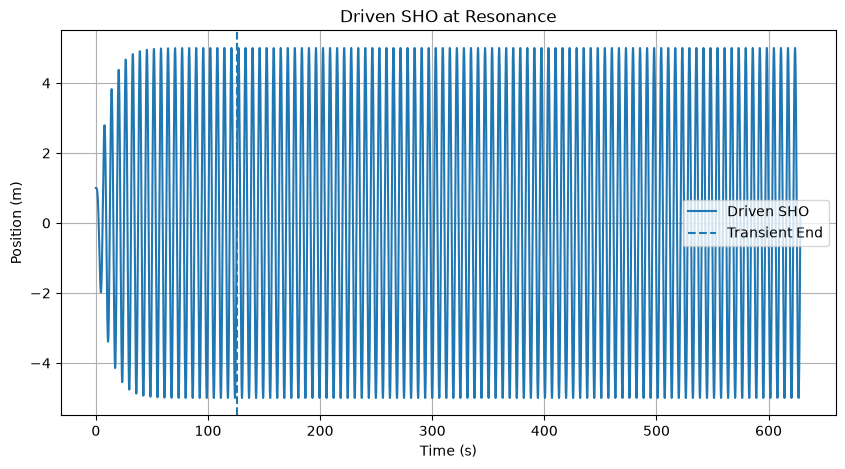

Peak Driving Frequency : 1.01
Peak Amplitude : 4.95
Natural Frequency : 1.0


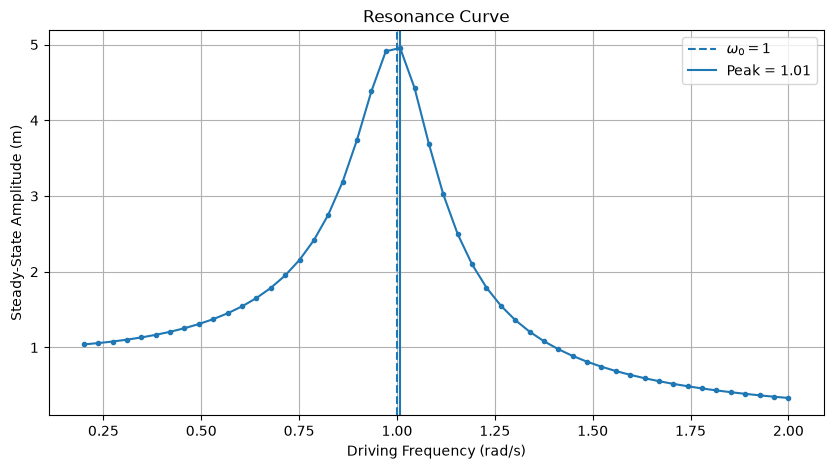

In [5]:

# Parameters
b = 0.2
F0 = 1.0

def simulate_driven_sho(omega_d, dt, n_periods=100):

    t_max = n_periods * T
    x, v = x0, v0

    ts = [0]
    xs = [x]
    vs = [v]

    t = 0.0

    while t < t_max:

        # Acceleration including damping and driving force
        a = -(k / m) * x - (b / m) * v + (F0 / m) * np.cos(omega_d * t)

        # Euler-Cromer
        v = v + a * dt
        x = x + v * dt

        t += dt

        ts.append(t)
        xs.append(x)
        vs.append(v)

    return np.array(ts), np.array(xs), np.array(vs)


# Show transient and steady state at resonance
omega_d = 1.0

t_drive, x_drive, v_drive = simulate_driven_sho(omega_d, dt, n_periods=100)

plt.figure(figsize=(10, 5))

plt.plot(t_drive, x_drive, label='Driven SHO')
plt.axvline(20*T, linestyle='--', label='Transient End')

plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('Driven SHO at Resonance')
plt.legend()
plt.grid()

plt.show()


# Resonance curve

omega_d_values = np.linspace(0.2, 2.0, 50)
amplitudes = []

for omega_d in omega_d_values:

    t_drive, x_drive, v_drive = simulate_driven_sho(omega_d, dt, n_periods=100)

    # Use only the final few periods to measure steady-state amplitude
    final_time = t_drive[-1]
    period_drive = 2 * np.pi / omega_d
    start_time = final_time - 5 * period_drive

    final_indices = t_drive >= start_time

    amplitude = np.max(np.abs(x_drive[final_indices]))
    amplitudes.append(amplitude)


# Resonance peak
peak_index = np.argmax(amplitudes)
omega_peak = omega_d_values[peak_index]
amplitude_peak = amplitudes[peak_index]

print("Peak Driving Frequency :", round(omega_peak, 2))
print("Peak Amplitude :", round(amplitude_peak, 2))
print("Natural Frequency :", round(omega, 2))


# Plot the curve
plt.figure(figsize=(10, 5))

plt.plot(omega_d_values, amplitudes, marker='o', markersize=3)
plt.axvline(omega, linestyle='--', label=r'$\omega_0 = 1$')
plt.axvline(omega_peak, label=f'Peak = {omega_peak:.2f}')

plt.xlabel('Driving Frequency (rad/s)')
plt.ylabel('Steady-State Amplitude (m)')
plt.title('Resonance Curve')
plt.legend()
plt.grid()

plt.show()

Interpretation: 

The amplitude of the oscillator peaks when the driving frequency is close to the natural frequency because as the driving frequency gets close to the natural frequency, energy is added to the system most efficiently. If the driving frequency was too low or too high, the energy added to the system is very inefficient because sometimes the driving force will oppose the direction of motion which will decrease the energy of the system. If the damping of the system decreases, the resonance has a higher peak. This is because decreasing the rate of energy loss from the system will in turn increase the efficiency of the driving force since less energy is being removed from the system causing a greater peak in amplitude.